In [3]:
from sklearn.model_selection import train_test_split

In [4]:
import pandas as pd
df=pd.read_csv("Admission_Predict.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [5]:
df.corr()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,1.000000,-0.097526,-0.147932,-0.169948,-0.166932,-0.088221,-0.045608,-0.063138,0.042336
GRE Score,-0.097526,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391,0.802610
TOEFL Score,-0.147932,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858,0.791594
University Rating,-0.169948,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783,0.711250
SOP,-0.166932,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029,0.675732
LOR,-0.088221,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859,0.669889
CGPA,-0.045608,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654,0.873289
Research,-0.063138,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000,0.553202
Chance of Admit,0.042336,0.802610,0.791594,0.711250,0.675732,0.669889,0.873289,0.553202,1.000000


In [6]:
#GRE SCORE - HIGLHY CORR
#TOEFL Score -HIGHLY CORR
#University Rating - HIGHLY CORR
#SOP - MODERATE
#LOP - MODERATE
#CGPA - HIGH
#RESEARCH - MODERATE

#IT IS A LINEAR DATA 


In [7]:
import matplotlib.pyplot as plt

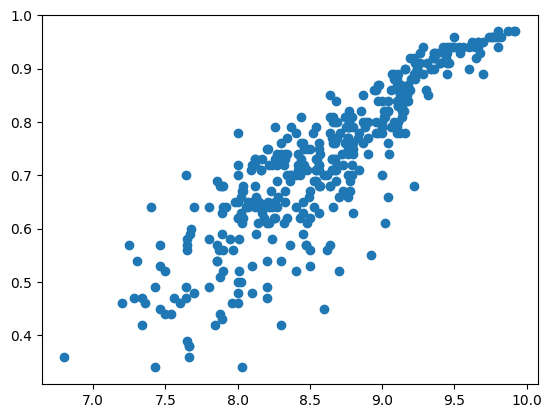

In [8]:
plt.scatter(df['CGPA'],df['Chance of Admit '])

In [9]:
x = df.drop(['Chance of Admit '],axis = 1)
y = df['Chance of Admit ']
xtrain,xtest , ytrain , ytest = train_test_split (x,y,train_size = 0.8 , random_state=43)

In [10]:
from sklearn.linear_model import LinearRegression
model=LinearRegression() 
model.fit(xtrain , ytrain)

LinearRegression()

In [11]:
ytrain

332    0.75
195    0.78
26     0.76
117    0.45
157    0.65
       ... 
277    0.70
305    0.74
255    0.79
320    0.75
324    0.67
Name: Chance of Admit , Length: 320, dtype: float64

In [12]:

ypred=model.predict(xtrain)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score

In [28]:
score = r2_score (ytrain,ypred)
print(score)

0.825777018052292


from r2 score (0.825777018052292) we can conclude that model captures patterns well

In [30]:
rmse = root_mean_squared_error(ytrain , ypred)
print(rmse)

0.0602921057704248


In [32]:
mae = mean_absolute_error(ytrain,ypred)
print(mae)

0.04415064811326681


from this we can conclude RMSE(0.06) is almost equal to MAE(0.04)

In [13]:
error=ytrain-ypred

In [14]:
error

332    0.081892
195    0.076823
26     0.026601
117   -0.048209
157    0.034157
         ...   
277    0.008523
305   -0.047970
255    0.078439
320    0.014370
324    0.008662
Name: Chance of Admit , Length: 320, dtype: float64

In [15]:
ypred

array([0.6681084 , 0.7031768 , 0.73339898, 0.49820946, 0.61584326,
       0.77143337, 0.92968706, 0.73283306, 0.82135927, 0.9633385 ,
       0.66141004, 0.95840702, 0.70096591, 0.77326634, 0.62418662,
       0.47659299, 0.63061526, 0.61964635, 0.63805129, 0.70666772,
       0.8093432 , 0.55599126, 0.84171978, 0.57457394, 0.84800157,
       0.80777474, 0.96958763, 0.93767451, 0.73494177, 0.65272052,
       0.79714663, 0.63261225, 0.87725008, 0.77246769, 0.84383432,
       0.81930112, 0.6715078 , 0.66949659, 0.83780824, 0.75148848,
       0.68362433, 0.63260124, 0.95665544, 0.64960071, 0.68110318,
       0.98961079, 0.6337932 , 0.77691642, 0.5582784 , 0.71661622,
       0.67683809, 0.96340434, 0.59118992, 0.61717663, 0.88946282,
       0.7028759 , 0.56163059, 0.52531357, 0.64253401, 0.68675698,
       0.90412415, 0.76634811, 0.57541327, 0.81362539, 0.84488771,
       0.70078321, 0.86404071, 0.60403599, 0.47326058, 0.91811403,
       0.70665786, 0.53675597, 0.78774014, 0.83383442, 0.65734

LETS CHECK FOR TEST DATA

In [34]:
test_pred = model.predict(xtest)
print(test_pred)

[0.56675833 0.52934274 0.64818389 0.7722027  0.69357879 0.57352535
 0.5895725  0.71617777 0.83738466 0.75649646 0.81024395 0.85691069
 0.51525949 0.83583731 0.93478683 0.86208836 0.98193556 0.67182918
 0.80922916 0.62965163 0.7356225  0.7324861  0.49590802 0.74042531
 0.83774157 0.66492059 0.71265214 0.82150066 0.62303673 0.88587725
 0.80789334 0.95136444 0.83075047 0.60126528 0.80114248 0.62368058
 0.72135972 0.59891576 0.81129597 0.67030219 0.69196457 0.76426727
 0.61388091 0.64984895 0.86368879 0.76525769 0.52171889 0.76712302
 0.887542   0.75325304 0.71339939 0.5185732  0.72852701 0.74291684
 0.62756195 0.67762952 0.93163684 0.78752773 0.65076263 0.53791181
 0.87598964 0.46133966 0.53772931 0.57037296 0.92870934 0.54564867
 0.84606189 0.66225921 0.8116424  0.47472375 0.77829787 0.84434487
 0.82795719 0.6303113  0.52031259 0.82768901 0.80293141 0.81427858
 0.766765   0.7452344 ]


In [36]:
test_r2 = r2_score(ytest,test_pred)
print(test_r2)

0.781873388737554


In [37]:
test_rmse = root_mean_squared_error(ytest,test_pred)
print(test_rmse)

0.06257718718331673


In [39]:
test_mae = mean_absolute_error(ytest,test_pred)
print(test_mae)

0.04560504430065475


HERE R2 score of test data (0.781873388737554) is nearly to r2_score of train data (0.825777018052292)

TRAIN : MAE = 0.04415064811326681 , RMSE =0.0602921057704248 

TEST : MAE = 0.04560504430065475 , RMSE = 0.06257718718331673

FROM THESE REGRESSION METRICS SCORE WE CAN CONCLUDE THAT THE MODEL IS READ FOR PREDICTION